In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Bidirectional, SimpleRNN
from tensorflow.keras.optimizers import Adam


In [2]:
df = pd.read_csv("NIFTY50.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

data = df[['Close']]
data.dropna(inplace=True)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)


/var/folders/z4/58kf2rh54s395f0pkgk591q00000gn/T/ipykernel_1611/2210257784.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(inplace=True)


In [3]:
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

WINDOW_SIZE = 60

X, y = create_sequences(scaled_data, WINDOW_SIZE)
X = X.reshape(X.shape[0], X.shape[1], 1)


In [4]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [5]:
model = Sequential()

model.add(Bidirectional(
    LSTM(64, return_sequences=True),
    input_shape=(X_train.shape[1], 1)
))

model.add(Dropout(0.3))

model.add(SimpleRNN(32))
model.add(Dropout(0.3))

model.add(Dense(1))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

model.summary()


/Users/krish/stock_ml/venv/lib/python3.11/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 128)        │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,977 (152.25 KB)

 Trainable params: 38,977 (152.25 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.1
)


Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0135 - val_loss: 4.6857e-04
Epoch 2/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0032 - val_loss: 1.9407e-04
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0019 - val_loss: 1.7547e-04
Epoch 4/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0016 - val_loss: 2.3815e-04
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0013 - val_loss: 1.9169e-04
Epoch 6/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0012 - val_loss: 2.0774e-04
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0012 - val_loss: 1.6761e-04
Epoch 8/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 9.8592e-04 - val_loss: 1.3557e-04
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 8.5080e-04 - val_loss: 1.4131e-04
Epoch 10/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 9.5858e-04 - val_loss: 1.3521e-04
Epoch 11/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 9.6162e-04 - val_loss: 1.8812e-04
Epo

In [7]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [8]:
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mae = mean_absolute_error(y_test_actual, predictions)
r2 = r2_score(y_test_actual, predictions)

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R2 Score: {r2}")


RMSE: 2.0095720926944125
MAE: 1.131157318026373
R2 Score: 0.9596130024335587


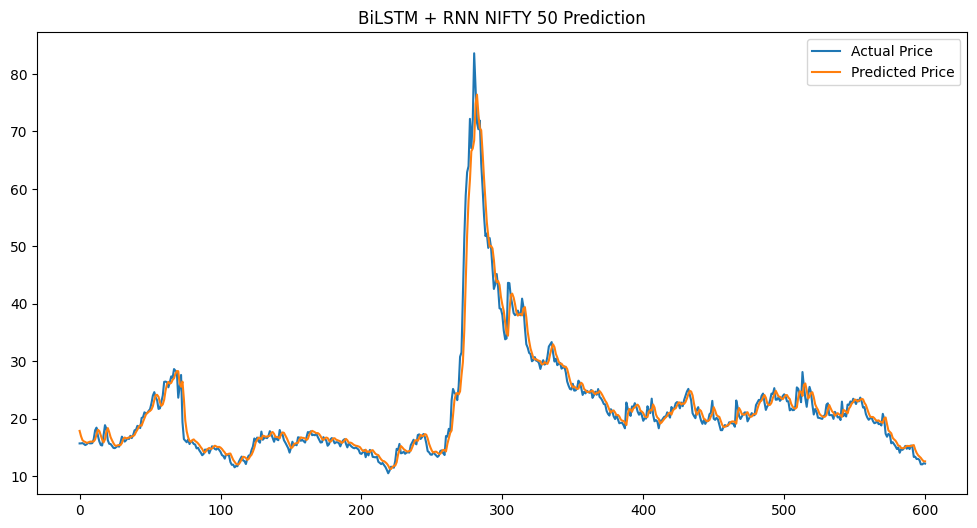

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.legend()
plt.title("BiLSTM + RNN NIFTY 50 Prediction")
plt.show()
